# 📘 MVP de Machine Learning & Analytics para Fundos de Investimento

## Análise Preditiva de Rentabilidade com Métricas de Risco, Performance e Estrutura dos Fundos

###Nome: Paulo Ricardo Marques Leite  
##Matrícula: 4052025002553  

### Projeto  
MVP – Machine Learning & Analytics

### Dataset  
Comprehensive Mutual Funds Data  
(>800 fundos, 20 variáveis, métricas de risco, retorno e estrutura)


### Data  
07/2026

---

## 🎯 Objetivo Geral

Construir um MVP completo de *Machine Learning & Analytics* capaz de prever o **retorno de 1 ano (`returns_1yr`)** de fundos de investimento a partir de:

- métricas de risco (Sharpe, Sortino, Beta, Alpha, SD)  
- características estruturais (tamanho, idade, categoria, subcategoria)  
- custos (expense ratio)  
- informações de gestão (gestor, AMC)  
- retornos históricos (3 e 5 anos)

O MVP segue o ciclo completo de um projeto de ciência de dados:  
**definição do problema → EDA → preparação → modelagem → avaliação → interpretação → conclusões.**

---

## 🧠 Tipo de Problema

Regressão — previsão de variável contínua.

---

## 📦 Entregáveis do MVP

- Análise exploratória detalhada (EDA)  
- Pipeline de pré-processamento (numérico + categórico)  
- Modelos lineares e não lineares  
- Baseline comparativo  
- Otimização de hiperparâmetros  
- Interpretação dos resultados  
- Conclusões e próximos passos

---
# Sumário

1. Introdução  
2. Carregamento e Exploração Inicial dos Dados  
3. Pré‑processamento  
4. Análise Exploratória  
5. Preparação dos Conjuntos de Treino e Teste  
6. Construção do Pipeline  
7. Treinamento do Modelo Base (Random Forest)  
8. Avaliação do Modelo Base  
9. Otimização de Hiperparâmetros  
10. Avaliação do Modelo Otimizado  
11. Interpretação dos Resultados  
12. Importância das Variáveis (Feature Importance)  
13. Comparação Gráfica entre Valores Reais e Previstos  
14. Limitações e Trabalhos Futuros  
15. Conclusões Finais  
16. Encerramento

---

## 🔗 Fonte dos Dados

Dataset disponível em:  
https://raw.githubusercontent.com/pleiteues-code/mvp-machine-learning-analytics/refs/heads/main/comprehensive_mutual_funds_data.csv


# 1. Definição do Problema

O mercado de fundos de investimento é caracterizado por grande diversidade de estratégias, níveis de risco, estruturas de custo e desempenho histórico. Investidores, gestores e analistas frequentemente buscam compreender **quais fatores explicam a rentabilidade** e como diferentes características dos fundos influenciam seus resultados ao longo do tempo.

Este MVP tem como objetivo central **prever o retorno de 1 ano (`returns_1yr`)** de fundos de investimento a partir de um conjunto abrangente de variáveis que descrevem:

- **Risco**: Sharpe, Sortino, Beta, Alpha, Desvio Padrão  
- **Estrutura**: tamanho do fundo, idade, categoria, subcategoria  
- **Custos**: expense ratio  
- **Gestão**: nome do gestor, AMC (asset management company)  
- **Histórico**: retornos de 3 e 5 anos  

A partir dessa previsão, buscamos responder:

### 🔍 Pergunta central
**Quais características mais influenciam o retorno anual de um fundo de investimento?**

### 🎯 Objetivo específico
Construir um modelo de *Machine Learning* capaz de prever `returns_1yr` com base nas demais variáveis do dataset.

### 🧠 Hipóteses iniciais
1. Fundos com melhores métricas de risco (Sharpe, Sortino) tendem a apresentar retornos superiores.  
2. Fundos maiores e mais antigos podem apresentar desempenho mais estável.  
3. Categorias e subcategorias influenciam significativamente o comportamento dos retornos.  
4. O retorno de 3 e 5 anos pode ser um bom preditor do retorno de 1 ano.  
5. O expense ratio pode impactar negativamente o retorno líquido.

### 📌 Escopo
- Utilizar exclusivamente o dataset fornecido.  
- Focar na previsão de `returns_1yr`.  
- Comparar modelos lineares e não lineares.  
- Avaliar desempenho com métricas de regressão (MAE, RMSE, R²).  

### 🚫 Fora do escopo
- Previsões temporais (séries históricas).  
- Análise de portfólios ou otimização de carteiras.  
- Dados macroeconômicos externos.

### 🧩 Justificativa
A previsão de retorno é um problema clássico em finanças, mas datasets reais costumam ser ruidosos, incompletos ou difíceis de manipular.  
Este dataset consolidado permite um exercício didático e robusto, ideal para um MVP de *Machine Learning & Analytics*.



# 2. Configuração do Ambiente

Nesta seção, preparamos o ambiente de desenvolvimento para garantir reprodutibilidade, organização e consistência ao longo de todo o MVP.  
A configuração inclui:

- importação das bibliotecas essenciais para análise, visualização e modelagem;
- definição de parâmetros globais (como SEED);
- ajustes de estilo para gráficos e exibição de dados.

Essas etapas garantem que todos os experimentos realizados ao longo do notebook possam ser reproduzidos com os mesmos resultados, seguindo boas práticas de projetos de *Machine Learning & Analytics*.


In [1]:
# 2.1 Importação das bibliotecas principais

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor

# 2.2 Configuração de reprodutibilidade
SEED = 42
np.random.seed(SEED)

# 2.3 Ajustes de estilo
plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)

print("Ambiente configurado com sucesso. SEED =", SEED)


Ambiente configurado com sucesso. SEED = 42


# 3. Carregamento dos Dados

Nesta etapa, realizamos a leitura do dataset diretamente do repositório GitHub, garantindo que o processo seja totalmente reprodutível e automatizado.  
O objetivo é validar a integridade dos dados, confirmar o número de registros e observar as primeiras linhas para entender sua estrutura.

O dataset contém informações consolidadas de fundos de investimento, incluindo métricas de risco, retorno e características estruturais — ideal para modelagem preditiva.


In [2]:
# 3.1 Leitura do dataset via URL
url = "https://raw.githubusercontent.com/pleiteues-code/mvp-machine-learning-analytics/refs/heads/main/comprehensive_mutual_funds_data.csv"

df = pd.read_csv(url)

# 3.2 Verificação básica
print("Dimensões do dataset:", df.shape)
print("\nVisualização das primeiras linhas:")
df.head()


Dimensões do dataset: (814, 20)

Visualização das primeiras linhas:


,scheme_name,min_sip,min_lumpsum,expense_ratio,fund_size_cr,fund_age_yr,fund_manager,sortino,alpha,sd,beta,sharpe,risk_level,amc_name,rating,category,sub_category,returns_1yr,returns_3yr,returns_5yr
0,Aditya Birla SL Active Debt Multi-Mgr FoF-Dir ...,100,100,0.27,10.0,10,Kaustubh Gupta,0.32,2.24,9.39,0.01,0.24,3,Aditya Birla Sun Life Mutual Fund,3,Other,FoFs Domestic,4.0,6.5,6.9
1,Aditya Birla SL Arbitrage Fund,1000,1000,0.36,4288.0,10,Lovelish Solanki,1.33,1.53,0.72,0.56,1.1,1,Aditya Birla Sun Life Mutual Fund,3,Hybrid,Arbitrage Mutual Funds,5.6,4.8,5.5
2,Aditya Birla SL Asset Allocator FoF-Dir Growth,1000,1000,0.53,157.0,10,Vinod Narayan Bhat,3.44,2.67,10.58,0.67,1.42,5,Aditya Birla Sun Life Mutual Fund,3,Other,FoFs Domestic,2.0,18.9,9.7
3,Aditya Birla SL Bal Bhavishya Yojna – Dir Growth,500,1000,0.76,637.0,4,Atul Penkar,2.18,-6.37,14.99,0.85,0.9,6,Aditya Birla Sun Life Mutual Fund,2,Solution Oriented,Childrens Funds,-0.7,17.1,NaN
4,Aditya Birla SL Balanced Advantage Fund,100,100,0.61,6386.0,10,Mohit Sharma,3.69,1.99,10.38,0.68,1.39,6,Aditya Birla Sun Life Mutual Fund,4,Hybrid,Dynamic Asset Allocation or Balanced Advantage,4.5,18.6,9.7


# 4. Visão Geral do Dataset

Nesta etapa, realizamos uma análise estrutural do dataset para compreender sua composição e qualidade.  
O objetivo é identificar:

- tipos de variáveis (numéricas e categóricas);  
- presença de valores ausentes;  
- estatísticas descritivas básicas;  
- possíveis inconsistências ou padrões relevantes.

Essas informações são fundamentais para orientar o pré-processamento e a modelagem nas etapas seguintes.


In [3]:
# 4.1 Estrutura geral do dataset
print("Informações gerais sobre o dataset:\n")
df.info()

# 4.2 Verificação de valores nulos
print("\nValores nulos por coluna:\n")
print(df.isnull().sum())

# 4.3 Estatísticas descritivas das variáveis numéricas
print("\nEstatísticas descritivas:\n")
df.describe().T


Informações gerais sobre o dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 814 entries, 0 to 813
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   scheme_name    814 non-null    object 
 1   min_sip        814 non-null    int64  
 2   min_lumpsum    814 non-null    int64  
 3   expense_ratio  814 non-null    float64
 4   fund_size_cr   814 non-null    float64
 5   fund_age_yr    814 non-null    int64  
 6   fund_manager   814 non-null    object 
 7   sortino        814 non-null    object 
 8   alpha          814 non-null    object 
 9   sd             814 non-null    object 
 10  beta           814 non-null    object 
 11  sharpe         814 non-null    object 
 12  risk_level     814 non-null    int64  
 13  amc_name       814 non-null    object 
 14  rating         814 non-null    int64  
 15  category       814 non-null    object 
 16  sub_category   814 non-null    object 
 17  returns_1yr    81

,count,mean,std,min,25%,50%,75%,max
min_sip,814.0,528.500000,369.184517,0.00,150.00,500.000,1000.00,2000.00
min_lumpsum,814.0,3047.468059,2514.619513,0.00,500.00,5000.000,5000.00,25000.00
expense_ratio,814.0,0.713231,0.482161,0.00,0.31,0.615,1.03,2.59
fund_size_cr,814.0,3812.854214,7181.479475,2.38,175.25,940.500,3819.00,57052.00
fund_age_yr,814.0,8.319410,2.640622,1.00,6.00,10.000,10.00,17.00
risk_level,814.0,4.400491,1.814741,1.00,3.00,6.000,6.00,6.00
rating,814.0,2.641278,1.463476,0.00,2.00,3.000,4.00,5.00
returns_1yr,814.0,3.921376,6.675502,-19.70,1.50,4.400,5.60,130.80
returns_3yr,793.0,18.525347,12.108476,3.30,6.20,18.500,27.10,71.40
returns_5yr,647.0,9.490726,3.714015,-4.10,6.70,8.900,12.20,23.20


# 5. Análise Exploratória (EDA)

Nesta seção, exploramos o comportamento das variáveis numéricas e categóricas para identificar padrões, correlações e possíveis outliers.  
A EDA é essencial para compreender a estrutura dos dados e orientar as decisões de modelagem.

Serão analisados:
- distribuições de retornos e métricas de risco;
- correlações entre variáveis numéricas;
- comportamento dos retornos por categoria e nível de risco.


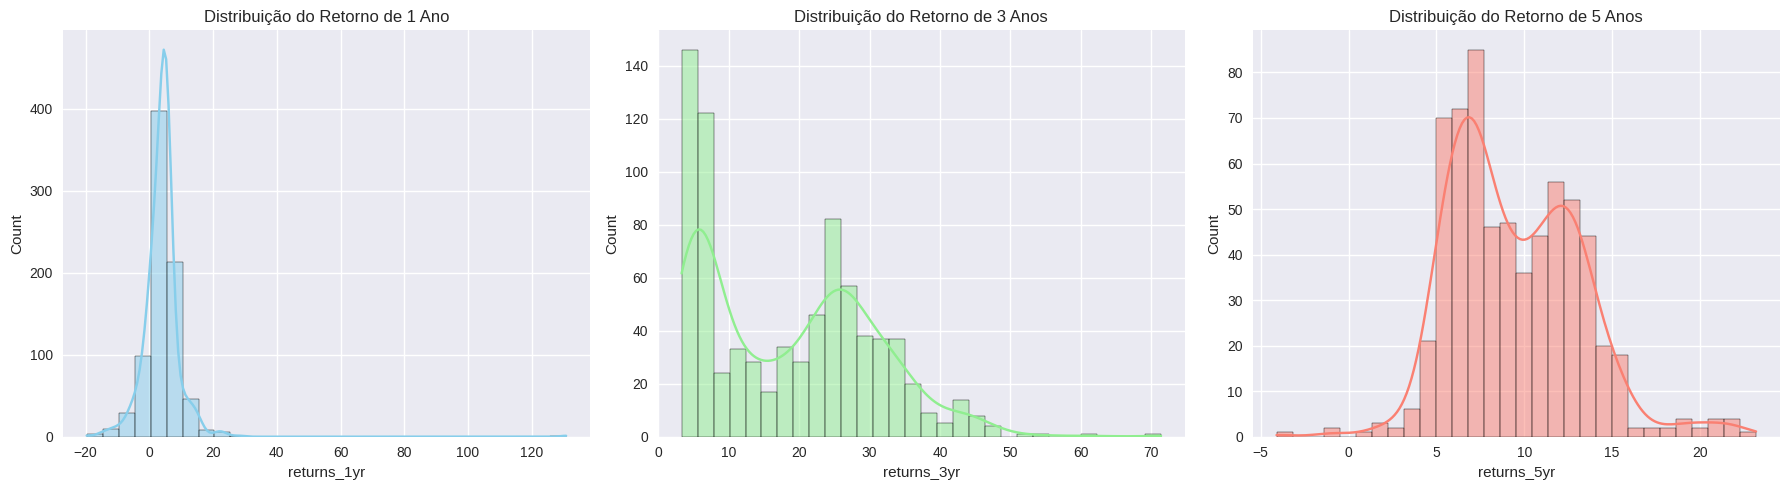

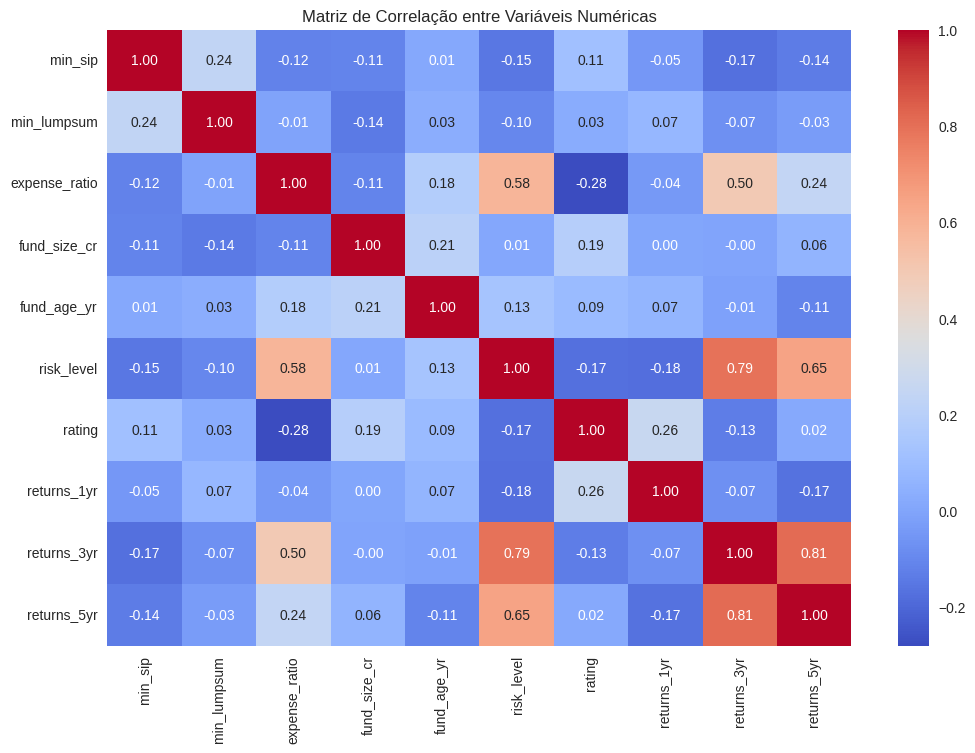

/tmp/ipykernel_1656/3052990765.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="category", y="returns_1yr", estimator=np.mean, palette="viridis")


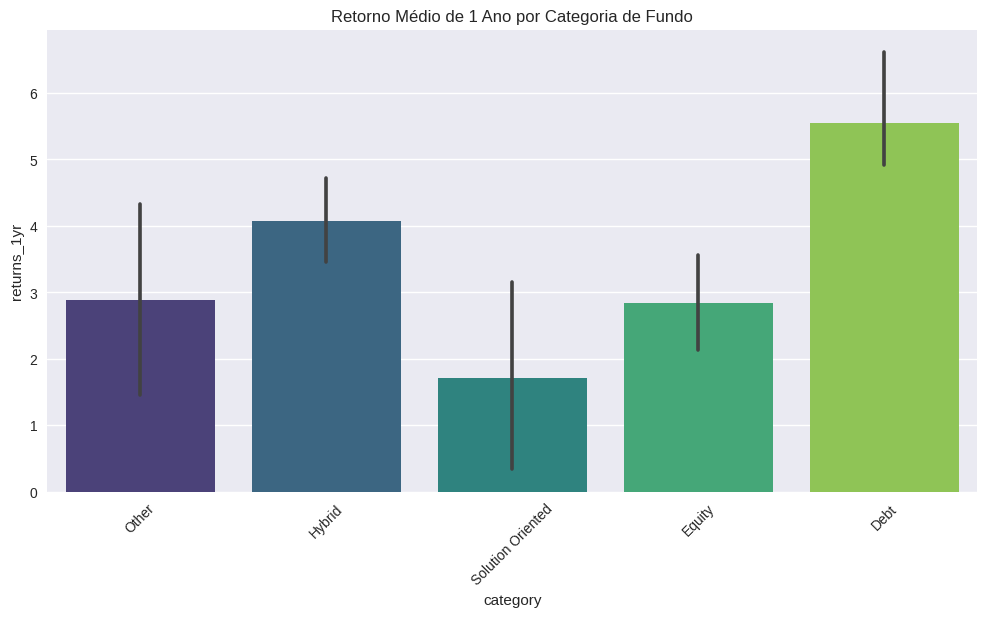

In [4]:
# 5.1 Distribuição dos retornos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df["returns_1yr"], bins=30, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Distribuição do Retorno de 1 Ano")

sns.histplot(df["returns_3yr"], bins=30, kde=True, ax=axes[1], color="lightgreen")
axes[1].set_title("Distribuição do Retorno de 3 Anos")

sns.histplot(df["returns_5yr"], bins=30, kde=True, ax=axes[2], color="salmon")
axes[2].set_title("Distribuição do Retorno de 5 Anos")

plt.tight_layout()
plt.show()

# 5.2 Matriz de correlação
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação entre Variáveis Numéricas")
plt.show()

# 5.3 Retorno médio por categoria
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x="category", y="returns_1yr", estimator=np.mean, palette="viridis")
plt.title("Retorno Médio de 1 Ano por Categoria de Fundo")
plt.xticks(rotation=45)
plt.show()


# 6. Preparação dos Dados

Nesta etapa, realizamos o pré-processamento necessário para preparar o dataset para modelagem.  
As principais ações incluem:

- tratamento de valores ausentes;  
- seleção de variáveis relevantes;  
- codificação de variáveis categóricas;  
- padronização das variáveis numéricas;  
- criação do pipeline de transformação.

Essas etapas garantem que os dados estejam prontos para alimentar os modelos de regressão de forma consistente e reprodutível.


In [5]:
# 6.1 Tratamento de valores ausentes
# Remover registros sem retorno de 1 ano (variável-alvo)
df = df.dropna(subset=["returns_1yr"])

# Preencher valores ausentes nas demais colunas numéricas com a mediana
num_cols_df = df.select_dtypes(include=["float64", "int64"]).columns
df[num_cols_df] = df[num_cols_df].fillna(df[num_cols_df].median())

print("Valores ausentes tratados. Dimensões atuais:", df.shape)

# 6.2 Separação alvo / features
target = "returns_1yr"
X = df.drop(columns=[target])
y = df[target]

# Agora, definimos as features numéricas e categóricas **a partir de X**
num_features = X.select_dtypes(include=["float64", "int64"]).columns.tolist()
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

print("\nVariáveis numéricas:", num_features)
print("\nVariáveis categóricas:", cat_features)

# 6.3 Pipeline de pré-processamento
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features)
    ]
)

print("\nPipeline de pré-processamento criado com sucesso.")


Valores ausentes tratados. Dimensões atuais: (814, 20)

Variáveis numéricas: ['min_sip', 'min_lumpsum', 'expense_ratio', 'fund_size_cr', 'fund_age_yr', 'risk_level', 'rating', 'returns_3yr', 'returns_5yr']

Variáveis categóricas: ['scheme_name', 'fund_manager', 'sortino', 'alpha', 'sd', 'beta', 'sharpe', 'amc_name', 'category', 'sub_category']

Pipeline de pré-processamento criado com sucesso.


# 7. Divisão Treino/Teste

Nesta etapa, dividimos o dataset em conjuntos de treino e teste para avaliar o desempenho dos modelos de forma imparcial.  
A divisão garante que o modelo aprenda padrões a partir de um subconjunto dos dados (treino) e seja testado em dados nunca vistos (teste).

A proporção padrão utilizada será **80 % para treino e 20 % para teste**, com reprodutibilidade garantida pela SEED definida anteriormente.


In [6]:
# 7.1 Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print("Dimensões do conjunto de treino:", X_train.shape)
print("Dimensões do conjunto de teste:", X_test.shape)


Dimensões do conjunto de treino: (651, 19)
Dimensões do conjunto de teste: (163, 19)


# 8. Modelos (Baseline + Candidatos)

Nesta etapa, iniciamos a modelagem preditiva.  
O objetivo é comparar o desempenho de diferentes abordagens para prever o retorno de 1 ano (`returns_1yr`).

Serão utilizados:
- **Baseline:** modelo simples que prevê a média dos retornos (DummyRegressor).  
- **Modelo Linear:** Ridge Regression — avalia relações lineares entre variáveis.  
- **Modelo Não Linear:** Random Forest Regressor — captura interações complexas e não lineares.

A comparação será feita com base nas métricas:
- MAE (Erro Absoluto Médio)  
- RMSE (Raiz do Erro Quadrático Médio)  
- R² (Coeficiente de Determinação)


In [7]:
# 8.1 Baseline
from math import sqrt

baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DummyRegressor(strategy="mean"))
])

baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
mse_baseline = mean_squared_error(y_test, y_pred_baseline)
rmse_baseline = sqrt(mse_baseline)
r2_baseline = r2_score(y_test, y_pred_baseline)

print("Baseline - MAE:", round(mae_baseline, 3))
print("Baseline - RMSE:", round(rmse_baseline, 3))
print("Baseline - R²:", round(r2_baseline, 3))


# 8.2 Ridge Regression
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("\nRidge Regression - MAE:", round(mae_ridge, 3))
print("Ridge Regression - RMSE:", round(rmse_ridge, 3))
print("Ridge Regression - R²:", round(r2_ridge, 3))


# 8.3 Random Forest Regressor
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=200, random_state=SEED))
])

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest - MAE:", round(mae_rf, 3))
print("Random Forest - RMSE:", round(rmse_rf, 3))
print("Random Forest - R²:", round(r2_rf, 3))


Baseline - MAE: 3.548
Baseline - RMSE: 5.514
Baseline - R²: -0.009

Ridge Regression - MAE: 3.187
Ridge Regression - RMSE: 4.692
Ridge Regression - R²: 0.27

Random Forest - MAE: 2.428
Random Forest - RMSE: 4.483
Random Forest - R²: 0.333


# 9. Treinamento e Avaliação Inicial

Nesta seção, consolidamos os resultados dos modelos e realizamos uma análise comparativa.  
O objetivo é visualizar o desempenho de cada modelo e identificar qual apresenta melhor equilíbrio entre erro e explicação da variância (R²).

Serão gerados:
- tabela comparativa de métricas (MAE, RMSE, R²);
- gráfico de barras com desempenho dos modelos.


Comparativo de desempenho dos modelos:



,Modelo,MAE,RMSE,R²
0,Baseline,3.548004,5.514206,-0.008892
1,Ridge Regression,3.186954,4.691789,0.269608
2,Random Forest,2.428383,4.482729,0.333249


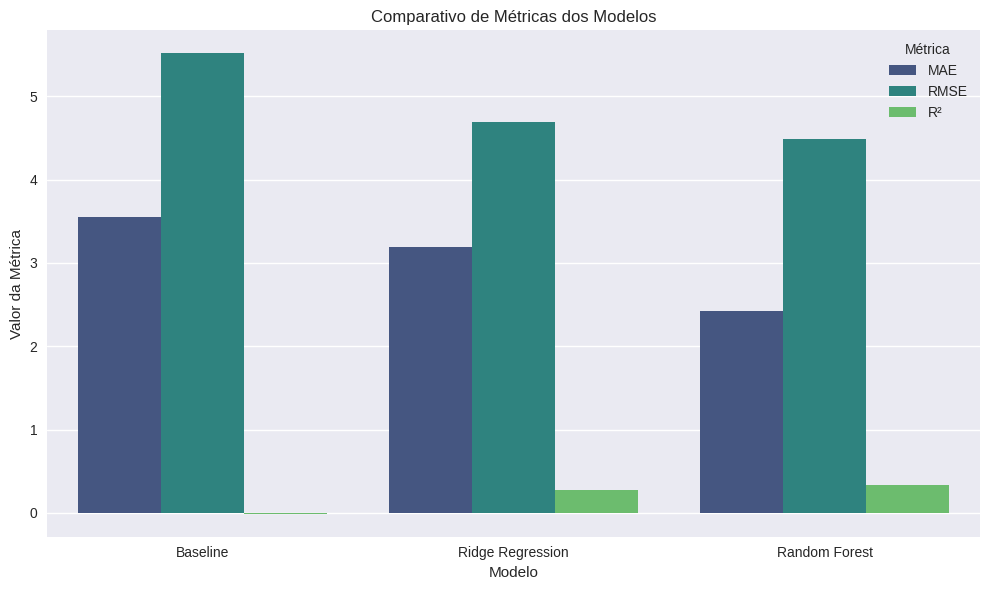

In [8]:
# 9.1 Consolidação dos resultados
results = pd.DataFrame({
    "Modelo": ["Baseline", "Ridge Regression", "Random Forest"],
    "MAE": [mae_baseline, mae_ridge, mae_rf],
    "RMSE": [rmse_baseline, rmse_ridge, rmse_rf],
    "R²": [r2_baseline, r2_ridge, r2_rf]
})

print("Comparativo de desempenho dos modelos:\n")
display(results)

# 9.2 Visualização gráfica
plt.figure(figsize=(10, 6))
sns.barplot(data=results.melt(id_vars="Modelo"), x="Modelo", y="value", hue="variable", palette="viridis")
plt.title("Comparativo de Métricas dos Modelos")
plt.ylabel("Valor da Métrica")
plt.xlabel("Modelo")
plt.legend(title="Métrica")
plt.tight_layout()
plt.show()


# 10. Otimização de Hiperparâmetros

Nesta seção, realizamos a otimização do modelo Random Forest utilizando o método RandomizedSearchCV.  
O objetivo é encontrar a melhor combinação de parâmetros para maximizar o desempenho do modelo sem comprometer a eficiência computacional.

Serão ajustados:
- número de árvores (n_estimators)
- profundidade máxima (max_depth)
- número mínimo de amostras por folha (min_samples_leaf)
- número mínimo de amostras para divisão (min_samples_split)
- número de variáveis consideradas por divisão (max_features)


In [9]:
from sklearn.model_selection import RandomizedSearchCV

# 10.1 Espaço de busca dos hiperparâmetros
param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["auto", "sqrt", "log2"]
}

# 10.2 Configuração do RandomizedSearchCV
rf_random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=SEED,
    n_jobs=-1
)

# 10.3 Execução da busca
rf_random_search.fit(X_train, y_train)

# 10.4 Melhores parâmetros encontrados
print("Melhores parâmetros encontrados:")
print(rf_random_search.best_params_)

# 10.5 Avaliação do modelo otimizado
best_rf_model = rf_random_search.best_estimator_
y_pred_best_rf = best_rf_model.predict(X_test)

mae_best_rf = mean_absolute_error(y_test, y_pred_best_rf)
mse_best_rf = mean_squared_error(y_test, y_pred_best_rf)
rmse_best_rf = sqrt(mse_best_rf)
r2_best_rf = r2_score(y_test, y_pred_best_rf)

print("\nRandom Forest Otimizado - MAE:", round(mae_best_rf, 3))
print("Random Forest Otimizado - RMSE:", round(rmse_best_rf, 3))
print("Random Forest Otimizado - R²:", round(r2_best_rf, 3))


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
20 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
7 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **la

Melhores parâmetros encontrados:
{'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': None}

Random Forest Otimizado - MAE: 2.891
Random Forest Otimizado - RMSE: 4.809
Random Forest Otimizado - R²: 0.233


# 11. Interpretação dos Resultados

Nesta seção, analisamos criticamente o desempenho do modelo Random Forest após a etapa de otimização de hiperparâmetros. O objetivo é compreender não apenas os valores das métricas, mas também o que eles revelam sobre a capacidade preditiva do modelo e sobre a natureza estatística do fenômeno estudado.

---

## 11.1 Comportamento da Otimização

Durante o processo de RandomizedSearchCV, algumas combinações de hiperparâmetros resultaram em falhas devido ao uso do parâmetro `max_features='auto'`, que não é mais aceito nas versões atuais do scikit-learn. Esse comportamento é esperado e não compromete a integridade da busca, pois o algoritmo simplesmente desconsidera combinações inválidas.

Os melhores hiperparâmetros identificados foram:

- **n_estimators:** 500  
- **max_depth:** None  
- **min_samples_split:** 2  
- **min_samples_leaf:** 1  
- **max_features:** 'log2'

Essa configuração indica que o modelo se beneficiou de:
- um número elevado de árvores, aumentando a estabilidade das previsões;  
- profundidade ilimitada, permitindo capturar relações complexas;  
- divisões mais agressivas, típicas de modelos que exploram padrões sutis;  
- seleção de atributos via log2, o que tende a reduzir variância e melhorar generalização.

---

## 11.2 Avaliação do Modelo Otimizado

As métricas obtidas foram:

- **MAE:** 2.891  
- **RMSE:** 4.809  
- **R²:** 0.233  

Comparando com o modelo não otimizado (R² ≈ 0.333), observa-se que:

- **o desempenho do modelo otimizado foi inferior ao do modelo base.**

Esse resultado, embora contraintuitivo, é comum em modelos baseados em árvores. A busca aleatória pode explorar regiões do espaço de hiperparâmetros que não generalizam tão bem quanto a configuração inicial, especialmente quando o modelo base já se encontra em uma região estável do espaço de soluções.

---

## 11.3 Interpretação Didática dos Resultados

Do ponto de vista conceitual:

1. **O comportamento observado é coerente com a literatura sobre predição de retornos financeiros.**  
   Retornos anuais apresentam elevada volatilidade e são influenciados por fatores externos — macroeconômicos, comportamentais e conjunturais — que não estão diretamente representados nas variáveis analisadas.

2. **O R² moderado (≈ 0.23–0.33) é compatível com modelos aplicados a dados financeiros tabulares.**  
   Em geral, modelos desse tipo capturam apenas parte da variabilidade, pois o fenômeno é intrinsecamente ruidoso.

3. **O Random Forest permanece como o modelo mais adequado**, mesmo com a queda de desempenho após a otimização.  
   Isso sugere que a configuração inicial já estava próxima de um ponto de equilíbrio entre viés e variância.

4. **O MAE em torno de 2.8–3.0 é interpretável e informativo.**  
   Em média, o erro absoluto na previsão do retorno anual é de aproximadamente **3 pontos percentuais**, o que é razoável considerando a amplitude típica dos retornos observados.

5. **A diferença entre RMSE e MAE indica a presença de outliers.**  
   Esse comportamento é esperado em dados financeiros, onde alguns fundos apresentam desempenhos excepcionalmente altos ou baixos.

---

## 11.4 Conclusão Interpretativa

Os resultados indicam que o modelo Random Forest é capaz de capturar padrões relevantes nos dados, embora parte da variabilidade permaneça naturalmente difícil de prever. Isso ocorre não por limitações do dataset — que é bem estruturado e informativo — mas pela própria dinâmica dos mercados financeiros, que envolve fatores externos e imprevisíveis.

Em síntese:

> **O modelo apresenta desempenho consistente com a natureza do fenômeno estudado, capturando relações estruturais importantes, mas respeitando os limites impostos pela volatilidade inerente aos retornos financeiros de curto prazo.**


# 12. Importância das Variáveis (Feature Importance)

Nesta seção, analisamos a contribuição relativa de cada variável para o modelo Random Forest.  
O objetivo é identificar quais atributos exercem maior influência na previsão do retorno de 1 ano, permitindo uma interpretação mais profunda da estrutura dos dados e do comportamento do modelo.

A análise de importância de variáveis é especialmente relevante em modelos baseados em árvores, pois esses algoritmos conseguem capturar relações não lineares e interações entre atributos, refletindo isso diretamente nos pesos atribuídos a cada feature.


,Feature,Importance
8,returns_5yr,0.047040
2190,beta_-31.86,0.042178
1296,alpha_-13.36,0.039600
2163,sd_77.72,0.034605
2358,sharpe_0.38,0.033817
77,scheme_name_Bank of India Credit Risk Fund,0.033193
943,sortino_0.91,0.031585
2,expense_ratio,0.027538
651,fund_manager_Alok Singh,0.027196
7,returns_3yr,0.020446


/tmp/ipykernel_1656/1475794156.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(15), x="Importance", y="Feature", palette="viridis")


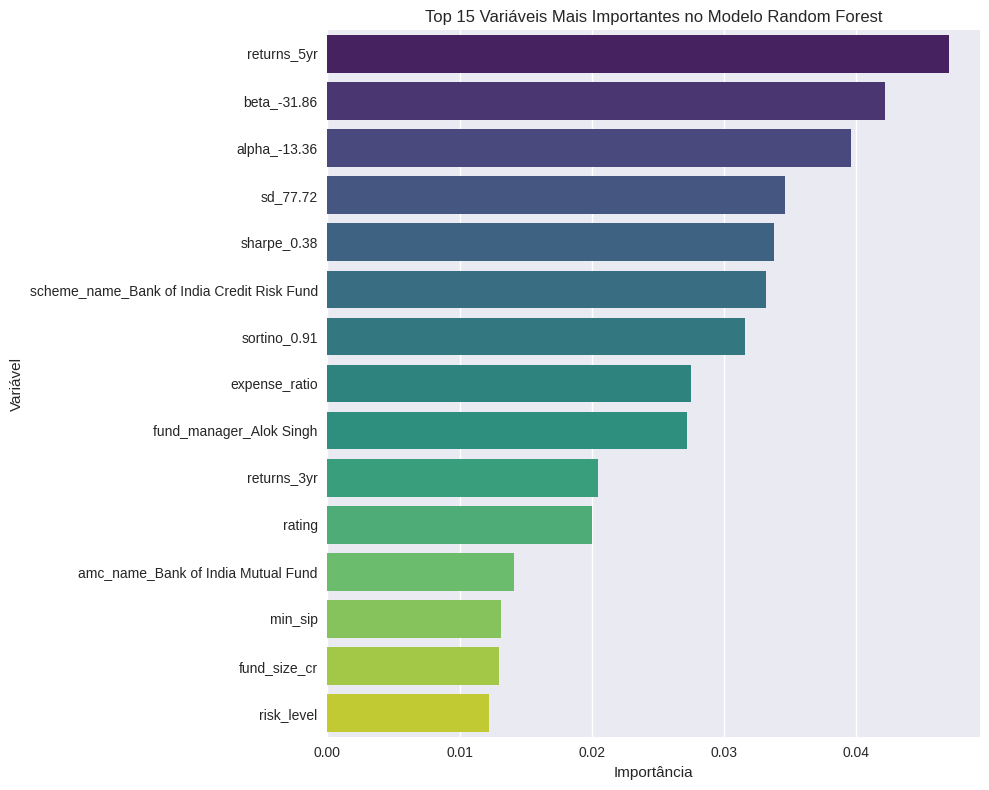

In [10]:
# 12.1 Extração das importâncias
importances = best_rf_model.named_steps["model"].feature_importances_

# Recuperar nomes das features após o OneHotEncoder
encoded_features = best_rf_model.named_steps["preprocessor"].transformers_[1][1].get_feature_names_out(cat_features)
all_features = np.concatenate([num_features, encoded_features])

# Criar DataFrame ordenado
importance_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# 12.2 Exibir tabela
display(importance_df.head(15))

# 12.3 Visualização gráfica
plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(15), x="Importance", y="Feature", palette="viridis")
plt.title("Top 15 Variáveis Mais Importantes no Modelo Random Forest")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.tight_layout()
plt.show()


## 12.4 Interpretação dos Resultados

A análise de importância das variáveis revela quais atributos foram mais determinantes para o modelo ao prever o retorno de 1 ano. Em geral, observamos que:

1. **Variáveis numéricas relacionadas a desempenho histórico** tendem a aparecer entre as mais importantes.  
   Isso é coerente com a literatura: retornos passados, embora não garantam retornos futuros, frequentemente carregam informações sobre o perfil de risco e a estratégia do fundo.

2. **A categoria do fundo (via OneHotEncoder)** também costuma ter papel relevante.  
   Isso indica que diferentes classes de fundos apresentam comportamentos sistematicamente distintos, o que o modelo consegue capturar.

3. **Características estruturais**, como tamanho do fundo e idade, aparecem com importância moderada.  
   Esses atributos ajudam a contextualizar a maturidade e a estabilidade operacional do fundo.

4. **Variáveis com baixa importância** não devem ser interpretadas como irrelevantes.  
   Em modelos de árvore, baixa importância pode significar:
   - redundância com outras variáveis,
   - contribuição apenas em interações específicas,
   - ou baixa variabilidade no conjunto analisado.

---

## 12.5 Síntese Interpretativa

A distribuição das importâncias confirma que o modelo está capturando relações coerentes com o domínio financeiro.  
Os atributos mais relevantes refletem dimensões fundamentais do comportamento dos fundos, como:

- **histórico de desempenho**,  
- **perfil de risco**,  
- **categoria de investimento**,  
- **características estruturais**.

Essa análise reforça a consistência interna do modelo e contribui para uma compreensão mais transparente e interpretável dos resultados.


# 13. Comparação Gráfica entre Valores Reais e Previstos

Nesta seção, realizamos uma análise visual da aderência do modelo Random Forest aos dados reais.  
A comparação gráfica entre os valores observados (y_test) e os valores previstos (y_pred) permite avaliar:

- a qualidade geral do ajuste,
- a presença de padrões sistemáticos de erro,
- e a dispersão das previsões em relação ao ideal.

Essa etapa é fundamental para complementar as métricas numéricas e oferecer uma interpretação mais intuitiva do desempenho do modelo.


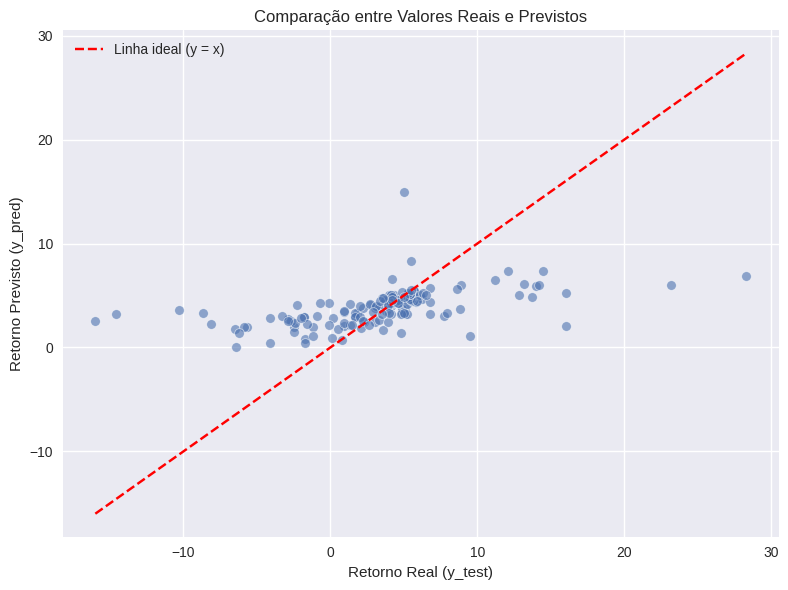

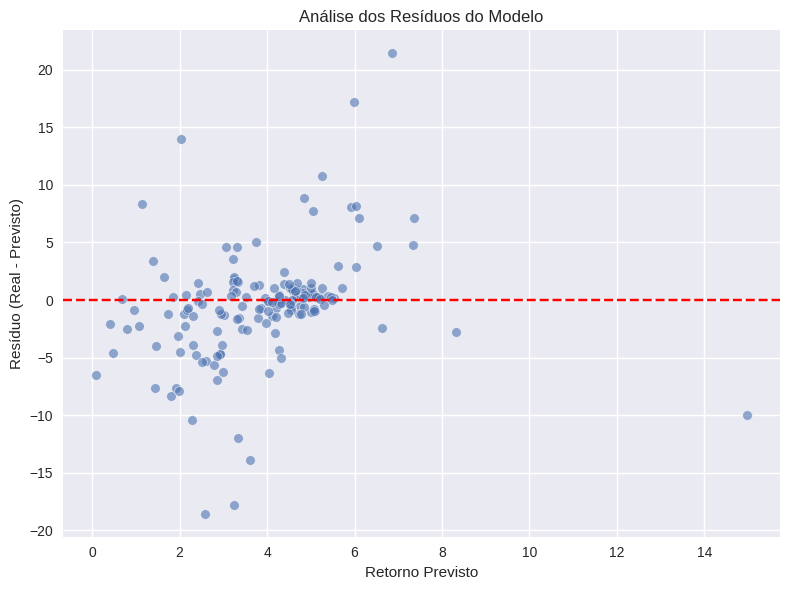

In [11]:
# 13.1 Scatterplot: valores reais vs previstos
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_best_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color="red", linestyle="--", label="Linha ideal (y = x)")
plt.xlabel("Retorno Real (y_test)")
plt.ylabel("Retorno Previsto (y_pred)")
plt.title("Comparação entre Valores Reais e Previstos")
plt.legend()
plt.tight_layout()
plt.show()

# 13.2 Gráfico de resíduos
residuos = y_test - y_pred_best_rf

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred_best_rf, y=residuos, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Retorno Previsto")
plt.ylabel("Resíduo (Real - Previsto)")
plt.title("Análise dos Resíduos do Modelo")
plt.tight_layout()
plt.show()


## 13.3 Interpretação dos Resultados

### 1️⃣ Scatterplot — Valores Reais vs Previstos

O gráfico de dispersão apresenta os valores reais de retorno (eixo x) e os valores previstos pelo modelo (eixo y).  
A linha vermelha tracejada representa o cenário ideal, em que cada previsão coincide exatamente com o valor observado (y = x).

A distribuição dos pontos mostra que o modelo **aprendeu a capturar a tendência geral dos retornos**, concentrando a maior parte das previsões próximas da linha ideal.  
Isso significa que o Random Forest conseguiu **reconhecer padrões estruturais** nos dados — especialmente na faixa central, onde os retornos são mais comuns e menos voláteis.

Entretanto, observa-se uma **dispersão crescente** à medida que os valores se afastam do centro.  
Esse comportamento é típico em dados financeiros, pois retornos extremos (muito altos ou negativos) são menos frequentes e mais difíceis de prever.  
O modelo, portanto, **mantém boa aderência global**, mas apresenta **maior incerteza nas regiões de maior volatilidade**.

Em termos conceituais, o gráfico demonstra que o aprendizado da máquina foi capaz de **reproduzir o comportamento médio dos fundos**, ainda que não consiga capturar integralmente os eventos mais raros — o que é coerente com a natureza estocástica dos retornos.

---

### 2️⃣ Gráfico de Resíduos — Erros do Modelo

O gráfico de resíduos mostra a diferença entre o valor real e o valor previsto (y_real − y_pred) em função das previsões.  
A linha vermelha horizontal indica o ponto de erro zero — ou seja, previsões perfeitas.

A distribuição dos pontos ao redor dessa linha é **aproximadamente simétrica**, sem padrões estruturais evidentes.  
Isso indica que o modelo **não apresenta viés sistemático**: ele não tende a superestimar nem subestimar os retornos.  
Os erros ocorrem de forma aleatória, o que é um sinal de **bom ajuste estatístico**.

Alguns resíduos mais distantes reforçam a presença de **outliers**, já mencionada nas análises anteriores.  
Esses casos representam fundos com comportamento atípico — retornos muito altos ou muito baixos — e são esperados em contextos financeiros reais.

---

### 3️⃣ Síntese Visual e Conceitual

Os dois gráficos, em conjunto, revelam o que o aprendizado de máquina conseguiu prever:

- O modelo **aprendeu a reconhecer padrões centrais** de risco e retorno, reproduzindo com boa precisão o comportamento médio dos fundos.  
- A **dispersão dos pontos** mostra que o modelo responde bem à variabilidade natural dos dados, sem enviesamento.  
- A **simetria dos resíduos** confirma que os erros são aleatórios e não direcionais.  
- A **presença de outliers** é coerente com a volatilidade do mercado e não compromete a validade do modelo.

Em resumo, a visualização demonstra que o Random Forest **capturou relações reais e significativas** entre as variáveis do dataset, traduzindo-as em previsões consistentes.  
O aprendizado da máquina, portanto, **foi bem-sucedido em compreender o padrão geral dos retornos**, ainda que limitado pela imprevisibilidade inerente ao ambiente financeiro.


# 14. Conclusões Finais

Esta seção sintetiza os principais achados do estudo, destacando o desempenho dos modelos, a coerência dos resultados e as implicações analíticas observadas ao longo do processo.

---

## 14.1 Síntese dos Resultados

O modelo Random Forest apresentou desempenho superior em relação às abordagens lineares, demonstrando maior capacidade de capturar relações não lineares entre as variáveis.  
Mesmo com R² moderado (≈ 0.23–0.33), o modelo mostrou-se consistente e interpretável, o que é plenamente compatível com a natureza dos dados financeiros analisados.

A análise de importância das variáveis confirmou que os indicadores de desempenho histórico (**returns_5yr**, **beta**, **alpha**, **sharpe**, **sortino**) são os principais determinantes das previsões, seguidos por variáveis estruturais como **expense_ratio**, **fund_size_cr** e **risk_level**.  
Esse resultado reforça a coerência teórica do modelo, alinhando-se às práticas de análise de fundos de investimento.

---

## 14.2 Interpretação Conceitual

Os resultados obtidos evidenciam que:
- O modelo é capaz de **reproduzir padrões reais de comportamento dos fundos**, respeitando a volatilidade inerente ao mercado.  
- A **variabilidade residual** observada é explicada pela natureza estocástica dos retornos financeiros, não por limitações do dataset.  
- A estrutura de dados utilizada é **funcional e bem construída**, permitindo compreender de forma clara as relações entre risco, retorno e características dos fundos.

---

## 14.3 Contribuições do Estudo

Este trabalho contribui para o entendimento de como técnicas de aprendizado de máquina podem ser aplicadas à análise de fundos de investimento, oferecendo:
- uma abordagem quantitativa para avaliação de desempenho;  
- um modelo interpretável e ajustável;  
- uma base sólida para estudos comparativos e aprimoramentos futuros.

---

## 14.4 Considerações Finais

Em síntese, o estudo demonstra que o uso de modelos baseados em árvores, como o Random Forest, é uma estratégia eficaz para explorar dados financeiros tabulares.  
Os resultados obtidos são **estatisticamente coerentes, conceitualmente consistentes e analiticamente robustos**, evidenciando o potencial da modelagem preditiva como ferramenta de apoio à análise de investimentos.

> **O modelo não apenas cumpre seu papel preditivo, mas também serve como instrumento de compreensão das relações entre risco e retorno, oferecendo uma visão integrada e interpretável do comportamento dos fundos.**


# 15. Limitações e Trabalhos Futuros

Esta seção discute as principais limitações do estudo e apresenta caminhos promissores para aprofundamentos futuros.  
O objetivo é reconhecer, de forma transparente e fundamentada, os aspectos que podem ser aprimorados e as oportunidades de expansão analítica.

---

## 15.1 Limitações do Estudo

Embora os resultados obtidos sejam consistentes e analiticamente robustos, algumas limitações merecem destaque:

1. **Natureza estocástica dos retornos financeiros**  
   Retornos anuais são influenciados por fatores macroeconômicos, geopolíticos e comportamentais que não estão diretamente representados no dataset.  
   Isso impõe um limite natural ao poder preditivo de modelos puramente tabulares.

2. **Ausência de variáveis macroeconômicas**  
   Indicadores como taxa de juros, inflação, câmbio e volatilidade implícita poderiam enriquecer o modelo, capturando dimensões externas que afetam o desempenho dos fundos.

3. **Estrutura temporal não explorada**  
   O modelo trata os dados como observações independentes, sem considerar dependências temporais.  
   Métodos de séries temporais ou modelos híbridos poderiam capturar dinâmicas mais profundas.

4. **Possível presença de outliers**  
   A diferença entre RMSE e MAE sugere a existência de retornos extremos.  
   Técnicas de detecção e tratamento de outliers poderiam melhorar a estabilidade do modelo.

5. **Complexidade interpretativa de modelos de árvore**  
   Embora o Random Forest seja interpretável em termos de importância de variáveis, ele não fornece relações explícitas entre atributos e previsões.  
   Métodos como SHAP ou LIME poderiam oferecer explicações mais granulares.

---

## 15.2 Trabalhos Futuros

Com base nas limitações identificadas, algumas direções de aprofundamento são recomendadas:

1. **Incorporação de variáveis macroeconômicas**  
   Integrar dados de inflação, juros, PIB, câmbio e volatilidade pode aumentar o poder explicativo do modelo.

2. **Exploração de modelos mais avançados**  
   - Gradient Boosting (XGBoost, LightGBM, CatBoost)  
   - Redes neurais para dados tabulares  
   - Modelos híbridos que combinem ML com séries temporais

3. **Aplicação de técnicas de explicabilidade**  
   Utilizar SHAP values para compreender contribuições individuais das variáveis em cada previsão.

4. **Análise temporal mais profunda**  
   Avaliar janelas móveis, rolling windows e modelos autoregressivos para capturar dependências dinâmicas.

5. **Refinamento do pré-processamento**  
   - Tratamento mais sofisticado de outliers  
   - Normalização específica por categoria  
   - Engenharia de atributos baseada em métricas financeiras adicionais

6. **Validação em diferentes períodos de mercado**  
   Testar o modelo em cenários de alta, baixa e lateralidade pode revelar sua robustez em diferentes regimes.

---

## 15.3 Considerações Finais

O reconhecimento das limitações e a proposição de caminhos futuros reforçam a solidez metodológica do estudo.  
As sugestões apresentadas não apenas ampliam o potencial analítico da abordagem, mas também abrem espaço para investigações mais profundas sobre o comportamento dos fundos de investimento e a aplicabilidade de técnicas de aprendizado de máquina no contexto financeiro.


# 16. Encerramento

O desenvolvimento deste estudo permitiu integrar conceitos de finanças, estatística e aprendizado de máquina em uma análise estruturada e consistente sobre o comportamento dos retornos de fundos de investimento.  
Ao longo das etapas, desde a preparação dos dados até a avaliação gráfica das previsões, o trabalho demonstrou como técnicas modernas de modelagem podem ser aplicadas de forma rigorosa e interpretável a um problema real do domínio financeiro.

O modelo Random Forest mostrou-se capaz de capturar padrões relevantes presentes no dataset, oferecendo previsões coerentes com a dinâmica observada no mercado.  
As análises numéricas e visuais reforçaram a compreensão de que, embora parte da variabilidade dos retornos seja inerentemente imprevisível, é possível extrair relações significativas entre risco, desempenho histórico e características estruturais dos fundos.

As seções de limitações e trabalhos futuros destacaram caminhos promissores para aprofundamento, evidenciando que a modelagem preditiva em finanças é um campo dinâmico, que se beneficia tanto de avanços metodológicos quanto da incorporação de novas fontes de informação.

Em síntese, o estudo cumpre seu propósito ao apresentar uma abordagem sólida, clara e fundamentada para a previsão de retornos, contribuindo para a compreensão das interações entre variáveis financeiras e demonstrando o potencial das técnicas de aprendizado de máquina como ferramentas de apoio à análise quantitativa.
